In [1]:
import scanpy as sc
import pandas as pd
import scipy.io

In [2]:
X = scipy.io.mmread("../data/GSE216999_Mancuso2022_RNAcounts.mtx").tocsr()


In [3]:
cells = pd.read_csv(
    "../data/GSE216999_Mancuso2022_RNAcounts_cellbarcodes.txt",
    header=None
)
cells.columns = ["cell"]

In [4]:
genes = pd.read_csv(
    "../data/GSE216999_Mancuso2022_RNAcounts_genes.txt",
    header=None
)
genes.columns = ["gene"]

In [5]:
cells = cells.iloc[1:]  # remove first row
print(cells)
# If the number is in the same string, split by space
cells["cell"] = cells["cell"].astype(str).str.split().str[-1]

# Remove quotes if present
cells["cell"] = cells["cell"].str.replace('"', '', regex=False)
print(cells)

                                     cell
1           1 "AAACCCAAGTCAGGGT-1_lib3.4"
2           2 "AAACCCAAGTTCCTGA-1_lib3.4"
3           3 "AAACCCACACCCATAA-1_lib3.4"
4           4 "AAACCCAGTAGTATAG-1_lib3.4"
5           5 "AAACCCAGTATCCCAA-1_lib3.4"
...                                   ...
127751  127751 "TTTGGTTTCGAACTGT-1_libNN"
127752  127752 "TTTGTCACAGCCTTTC-1_libNN"
127753  127753 "TTTGTCACAGGTGCCT-1_libNN"
127754  127754 "TTTGTCATCACAGGCC-1_libNN"
127755  127755 "TTTGTCATCATTCACT-1_libNN"

[127755 rows x 1 columns]
                             cell
1       AAACCCAAGTCAGGGT-1_lib3.4
2       AAACCCAAGTTCCTGA-1_lib3.4
3       AAACCCACACCCATAA-1_lib3.4
4       AAACCCAGTAGTATAG-1_lib3.4
5       AAACCCAGTATCCCAA-1_lib3.4
...                           ...
127751   TTTGGTTTCGAACTGT-1_libNN
127752   TTTGTCACAGCCTTTC-1_libNN
127753   TTTGTCACAGGTGCCT-1_libNN
127754   TTTGTCATCACAGGCC-1_libNN
127755   TTTGTCATCATTCACT-1_libNN

[127755 rows x 1 columns]


In [6]:
genes = genes.iloc[1:]

In [ ]:
print(genes)

In [7]:
adata = sc.AnnData(X.T)

adata.obs_names = cells["cell"].values
adata.var_names = genes["gene"].values

In [8]:
metadata = pd.read_csv("../data/GSE216999_Mancuso2022_metadata.csv")
print(metadata)

                         cell_id    umap_1    umap_2  \
0        AAACGCTAGCTTCTAG-1_lib8 -5.200307 -3.366044   
1        AAAGAACCACCAAAGG-1_lib8 -4.850867 -2.619076   
2        AAAGAACCACGCGGTT-1_lib8 -3.155308 -4.831426   
3        AAAGGGCGTCTCAGGC-1_lib8 -4.768488 -2.865388   
4        AAAGTCCTCTTCTGGC-1_lib8 -5.109416 -1.460247   
...                          ...       ...       ...   
127750  TTTCACACAGGTCCGT-1_lib25  3.650309 -2.626765   
127751  TTTCATGTCACACCGG-1_lib25  2.351479 -3.060695   
127752  TTTCGATAGCCGGATA-1_lib25  2.131492 -3.048455   
127753  TTTCGATCAGGCCCTA-1_lib25  0.893381 -3.269467   
127754  TTTGGAGCACATAGCT-1_lib25  2.768476 -2.921229   

                          cell.state_v2.1 mouse.id mouse.genotype  \
0       Antigen-presenting response (HLA)    MG447       APP-NLGF   
1       Antigen-presenting response (HLA)    MG447       APP-NLGF   
2       Antigen-presenting response (HLA)    MG447       APP-NLGF   
3       Antigen-presenting response (HLA)    MG447 

In [9]:
# Select metadata rows that match the AnnData cells
metadata_matched = metadata[metadata["cell_id"].isin(adata.obs_names)].copy()

# Now assign to adata.obs safely
adata.obs = metadata_matched.set_index("cell_id").loc[adata.obs_names].copy()

In [ ]:
print(adata)

In [10]:
wildtype = adata[adata.obs["mouse.genotype"] == "APP-WT"]

In [11]:
sc.pp.filter_genes(wildtype, min_cells=3)
sc.pp.normalize_total(wildtype)
sc.pp.log1p(wildtype)
sc.pp.highly_variable_genes(wildtype)
wildtype = wildtype[:, wildtype.var.highly_variable]
sc.tl.pca(wildtype)
sc.pp.neighbors(wildtype, n_neighbors=50, n_pcs=10)
# sc.tl.diffmap(wildtype, n_comps=10)
# sc.tl.tsne(wildtype)
sc.tl.umap(wildtype)

/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number
/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:385: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca
/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


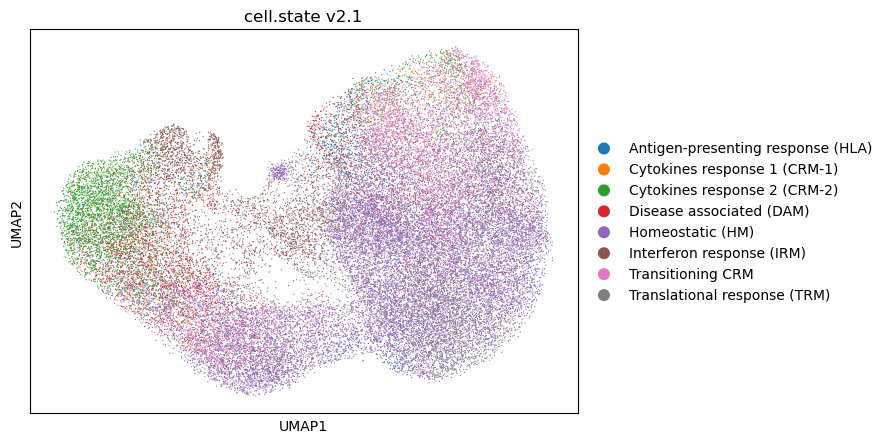

In [12]:
sc.pl.scatter(wildtype, basis="umap", color="cell.state_v2.1", frameon=True)

In [12]:
import matplotlib.pyplot as plt
import numpy as np

/var/folders/4k/lkwwfnw57332tg4t_n8tqy5m0000gn/T/ipykernel_19945/2702542682.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(categories))


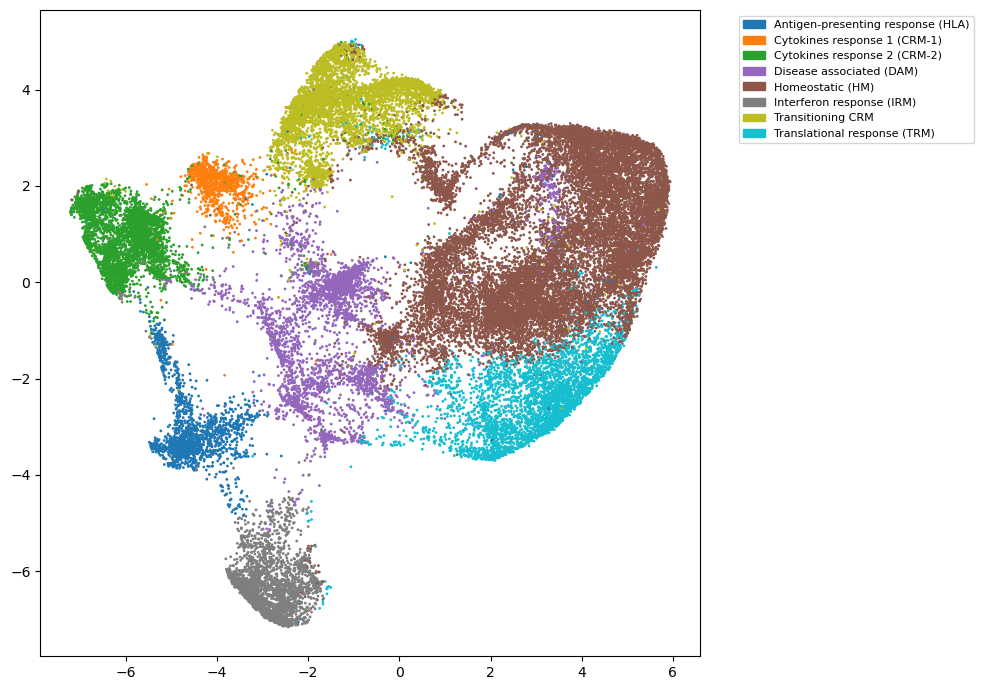

In [23]:
import matplotlib.patches as mpatches

states = wildtype.obs["cell.state_v2.1"].astype("category").reset_index(drop=True)
umap_0 = wildtype.obs["umap_1"].to_numpy()
umap_1 = wildtype.obs["umap_2"].to_numpy()

states = states.astype("category")
categories = states.cat.categories.tolist()
cmap = plt.cm.get_cmap("tab10", len(categories))
color_dict = {cat: cmap(i) for i, cat in enumerate(categories)}

colors = np.array([color_dict[s] for s in states])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(umap_0, umap_1, c=colors, s=1)

patches = [mpatches.Patch(color=color_dict[cat], label=cat) for cat in categories]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [15]:
root = umap_0.argmax()
umap = np.column_stack([umap_0, umap_1])
wildtype.obsm["X_umap"] = umap

In [16]:
from py_monocle import (
    learn_graph,
    order_cells,
    compute_cell_states,
    regression_analysis,
    differential_expression_genes,
)

In [ ]:
sc.pp.neighbors(wildtype, n_neighbors=50, use_rep='X_umap')
sc.tl.leiden(wildtype)
leiden = wildtype.obs["leiden"].to_numpy(dtype=int)
projected_points, mst, centroids = learn_graph(matrix=umap, clusters=leiden)
pseudotime = order_cells(
    umap, centroids,
    mst=mst,
    projected_points=projected_points,
    root_cells=[root],
)

/var/folders/4k/lkwwfnw57332tg4t_n8tqy5m0000gn/T/ipykernel_19557/1167355495.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(wildtype)


In [ ]:
plt.figure(1, (10, 6))
plt.title("Pseudotime")
plt.scatter(umap[:, 0], umap[:, 1], c=pseudotime, s=1, cmap="plasma")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

In [24]:
pathology = adata[adata.obs["mouse.genotype"] == "APP-NLGF"]

In [25]:
umap_1 = pathology.obs["umap_1"]
umap_2 = pathology.obs["umap_2"]
umap = np.column_stack([umap_1, umap_2])
umap



array([[ 3.35342186, -1.68264305],
       [ 2.80318897, -0.64247542],
       [ 3.92746013,  1.96414936],
       ...,
       [-2.81092341, -7.0005058 ],
       [ 1.57683819, -0.69910201],
       [-2.44713468, -0.95483738]])

In [26]:
sc.pp.filter_genes(pathology, min_cells=3)
sc.pp.normalize_total(pathology)
sc.pp.log1p(pathology)
sc.pp.highly_variable_genes(pathology)
pathology = pathology[:, pathology.var.highly_variable]
sc.tl.pca(pathology)
sc.pp.neighbors(pathology, n_neighbors=50, n_pcs=10)
# sc.tl.diffmap(pathology, n_comps=10)
# sc.tl.tsne(pathology)
sc.tl.umap(pathology)

/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number
/opt/miniconda3/envs/traveler/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:385: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


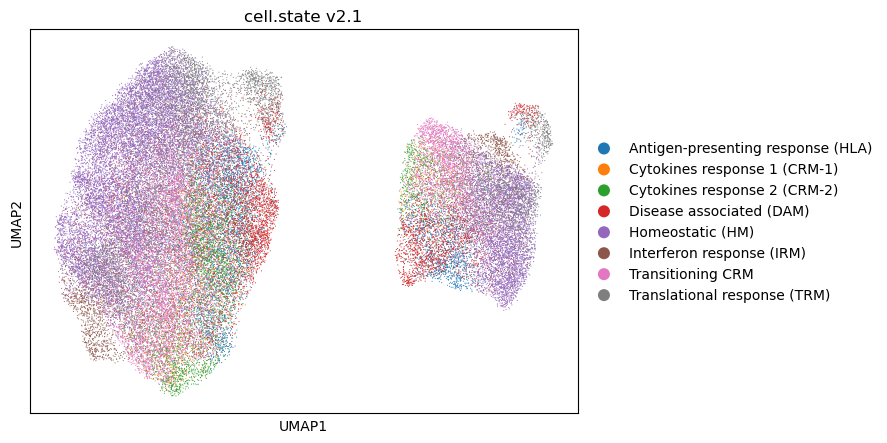

In [27]:
sc.pl.scatter(pathology, basis="umap", color="cell.state_v2.1", frameon=True)

/var/folders/4k/lkwwfnw57332tg4t_n8tqy5m0000gn/T/ipykernel_19945/4199871581.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(categories))


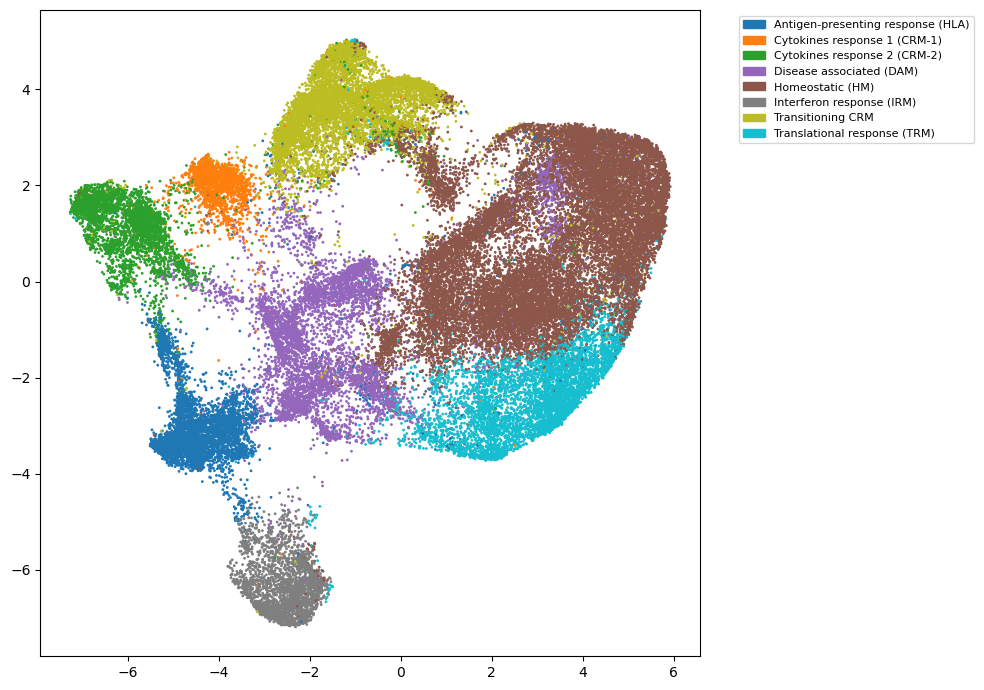

In [28]:
import matplotlib.patches as mpatches

states = pathology.obs["cell.state_v2.1"].astype("category").reset_index(drop=True)
umap_0 = pathology.obs["umap_1"].to_numpy()
umap_1 = pathology.obs["umap_2"].to_numpy()

states = states.astype("category")
categories = states.cat.categories.tolist()
cmap = plt.cm.get_cmap("tab10", len(categories))
color_dict = {cat: cmap(i) for i, cat in enumerate(categories)}

colors = np.array([color_dict[s] for s in states])

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(umap_0, umap_1, c=colors, s=1)

patches = [mpatches.Patch(color=color_dict[cat], label=cat) for cat in categories]
ax.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

In [12]:
len(wildtype)

39090

In [13]:
len(pathology)

53594